# Figure 4 with the bond-index pipeline


In [1]:
# Haldane model, only modeling pz C orbitals
import sys
import json
from pathlib import Path

from pythtb import *
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Polygon
from scipy.ndimage import gaussian_filter1d
from tqdm import tqdm

import TBLR2 as TBLR                          # Nish's code, TBLR2.py in this folder

OUT = Path('fig4_minimal_output'); OUT.mkdir(exist_ok=True)

A_CELL = 3 * np.sqrt(3) / 2                   # primitive-cell area (a^2), NN bond a = 1

## 1. Haldane model

In [2]:
# define lattice vectors (scaled by sqrt3 so that the NN C-C bond is 1)
s3 = np.sqrt(3)
lat_vecs = [[s3, 0], [s3 / 2, s3 * np.sqrt(3) / 2]]
# define coordinates of orbitals
orb_vecs = [[1 / 3, 1 / 3], [2 / 3, 2 / 3]]
lat = Lattice(lat_vecs, orb_vecs, periodic_dirs=...)

# make two dimensional tight-binding Haldane model
haldane = TBModel(lat)

# set model parameters
delta = 0.0
t = -1.0
t2 = 1.0 * np.exp(-1j * np.pi / 2)     # = -1i   (Figure 4: |t2| = t1, chirality with C = +1)
t2c = t2.conjugate()

# set on-site energies
haldane.set_onsite([-delta, delta])
# set hoppings (one for each connected pair of orbitals)
# (amplitude, i, j, [lattice vector to cell containing j])
haldane.set_hop(t, 0, 1, [0, 0])
haldane.set_hop(t, 1, 0, [1, 0])
haldane.set_hop(t, 1, 0, [0, 1])
# add second neighbour complex hoppings
haldane.set_hop(t2, 0, 0, [1, 0])
haldane.set_hop(t2, 1, 1, [1, -1])
haldane.set_hop(t2, 1, 1, [0, 1])
haldane.set_hop(t2c, 1, 1, [1, 0])
haldane.set_hop(t2c, 0, 0, [1, -1])
haldane.set_hop(t2c, 0, 0, [0, 1])
print(haldane)

----------------------------------------
       Tight-binding model report       
----------------------------------------
r-space dimension           = 2
k-space dimension           = 2
periodic directions         = [0, 1]
spinful                     = False
number of spin components   = 1
number of electronic states = 2
number of orbitals          = 2

Lattice vectors (Cartesian):
  # 0 ===> [ 1.732,  0.000]
  # 1 ===> [ 0.866,  1.500]
Volume of unit cell (Cartesian) = 2.598 [A^d]

Reciprocal lattice vectors (Cartesian):
  # 0 ===> [ 3.628, -2.094]
  # 1 ===> [ 0.000,  4.189]
Volume of reciprocal unit cell = 15.195 [A^-d]

Orbital vectors (Cartesian):
  # 0 ===> [ 0.866,  0.500]
  # 1 ===> [ 1.732,  1.000]

Orbital vectors (fractional):
  # 0 ===> [ 0.333,  0.333]
  # 1 ===> [ 0.667,  0.667]
----------------------------------------
Site energies:
  < 0 | H | 0 > = -0.000 
  < 1 | H | 1 > =  0.000 
Hoppings:
  < 0 | H | 1  + [ 0.0 ,  0.0 ] > = -1.0000+0.0000j
  < 1 | H | 0  + [ 1.0 , 

## 2. Molecules and flakes


In [3]:
#make supercell for benzene
supercell_1 = haldane.make_supercell(np.array([[2,0],[0,2]]))
benzene = supercell_1.cut_piece(1, 1, glue_edges=False) #make it non-periodic in both directions
benzene = benzene.cut_piece(1, 0, glue_edges=False)
benzene.remove_orb(7)
benzene.remove_orb(0)

#Make large enough supercell to hold coronene
supercell_2 = haldane.make_supercell(np.array([[4,0],[0,4]]))
coronene = supercell_2.cut_piece(1, 1, glue_edges=False) #make it non-periodic in both directions
coronene = coronene.cut_piece(1, 0, glue_edges=False)
#Get these orbitals from plotting orbitals individually.. Don't combine remove to a list of orbitals, it gives error.
coronene.remove_orb(31)
coronene.remove_orb(30)
coronene.remove_orb(29)
coronene.remove_orb(23)
coronene.remove_orb(8)
coronene.remove_orb(2)
coronene.remove_orb(1)
coronene.remove_orb(0)


def hexagonal_piece(n_super, keep_centre):
    # Cut an n_super x n_super supercell and keep the vertices of the hexagons whose centre
    # (a lattice point, relative to the middle of the supercell) passes keep_centre(i, j).
    A = haldane.get_lat_vecs()
    piece = haldane.make_supercell(np.array([[n_super, 0], [0, n_super]]))
    piece = piece.cut_piece(1, 1, glue_edges=False).cut_piece(1, 0, glue_edges=False)
    middle = (n_super // 2) * (A[0] + A[1])
    centres = np.array([middle + i * A[0] + j * A[1] for i in range(-n_super, n_super + 1)
                        for j in range(-n_super, n_super + 1) if keep_centre(i, j)])
    pos = piece.get_orb_vecs(cartesian=True)
    on_a_hexagon = np.linalg.norm(pos[:, None] - centres[None], axis=-1).min(axis=1) < 1 + 1e-6
    for orb in sorted(np.where(~on_a_hexagon)[0], reverse=True):   # one at a time, DESCENDING
        piece.remove_orb(int(orb))                                  # (a list leaves stale hopping indices)
    assert all(h['to_orbital'] < piece.norb and h['from_orbital'] < piece.norb for h in piece.hoppings)
    return piece


a1, a2 = haldane.get_lat_vecs()
flake96 = hexagonal_piece(12, lambda i, j: np.linalg.norm(i * a1 + j * a2) < 5.3)
flake864 = hexagonal_piece(26, lambda i, j: max(abs(i), abs(j), abs(i + j)) <= 11)
for name, m in [('benzene', benzene), ('coronene', coronene), ('flake96', flake96), ('flake864', flake864)]:
    print(f'{name:9s} {m.norb:4d} orbitals')

benzene      6 orbitals
coronene    24 orbitals
flake96     96 orbitals
flake864   864 orbitals


In [4]:
# Figure-4 reference geometries (lattice.py), used only to give the orbitals Figure 4's labels
def benzene_positions():
    ang = np.deg2rad(60.0 * np.arange(6))                 # site n at 60*n deg
    return np.column_stack([np.cos(ang), np.sin(ang)])


def coronene_positions():
    pos = {}
    for i, dg in {7: 210, 8: 150, 9: 90, 16: 30, 15: 330, 14: 270}.items():
        pos[i] = np.array([np.cos(np.deg2rad(dg)), np.sin(np.deg2rad(dg))])
    for i, dg in {6: 210, 2: 150, 10: 90, 17: 30, 21: 330, 13: 270}.items():
        pos[i] = 2.0 * np.array([np.cos(np.deg2rad(dg)), np.sin(np.deg2rad(dg))])
    rim_dir = {3: 90, 1: 210, 4: 150, 11: 30, 18: 90, 23: 330, 22: 30, 20: 270, 19: 330, 12: 210, 5: 270, 0: 150}
    bof = {3: 2, 1: 2, 4: 10, 11: 10, 18: 17, 23: 17, 22: 21, 20: 21, 19: 13, 12: 13, 5: 6, 0: 6}
    for i, dg in rim_dir.items():
        pos[i] = pos[bof[i]] + np.array([np.cos(np.deg2rad(dg)), np.sin(np.deg2rad(dg))])
    return np.array([pos[i] for i in range(24)])


def hexagonal_flake(rcut=5.3):
    a1, a2 = s3 * np.array([1.0, 0.0]), s3 * np.array([0.5, np.sqrt(3) / 2])
    centers = [m * a1 + n * a2 for m in range(-6, 7) for n in range(-6, 7)]
    verts, vid = [], {}
    for c in [c for c in centers if np.linalg.norm(c) < rcut]:
        for a in np.deg2rad(90 + 60.0 * np.arange(6)):
            p = c + np.array([np.cos(a), np.sin(a)])
            key = (round(p[0], 4), round(p[1], 4))
            if key not in vid:
                vid[key] = len(verts); verts.append(p)
    return np.array(verts)


def fig4_numbering(model, fig4_pos):
    # fig4_id[i] = Figure-4 label of pythtb orbital i (positions matched after centring,
    # trying rotations in steps of 30 deg)
    p = model.get_orb_vecs(cartesian=True)
    p = p - p.mean(axis=0)
    for k in range(12):
        th = np.deg2rad(30 * k)
        rot = np.array([[np.cos(th), -np.sin(th)], [np.sin(th), np.cos(th)]])
        d = np.linalg.norm((p @ rot.T)[:, None] - fig4_pos[None], axis=-1)
        if d.min(axis=1).max() < 1e-6:
            return d.argmin(axis=1), 30 * k


models = {'benzene': benzene, 'coronene': coronene, 'flake96': flake96}
fig4_pos = {'benzene': benzene_positions(), 'coronene': coronene_positions(), 'flake96': hexagonal_flake()}
fig4_id = {}
for name, m in models.items():
    fig4_id[name], rot = fig4_numbering(m, fig4_pos[name])
    print(f'{name:9s} rotated by {rot:3d} deg;  pythtb -> Fig 4 labels: '
          f'{"identity" if (fig4_id[name] == np.arange(m.norb)).all() else fig4_id[name][:12]}')

benzene   rotated by  30 deg;  pythtb -> Fig 4 labels: [4 3 2 5 0 1]
coronene  rotated by   0 deg;  pythtb -> Fig 4 labels: identity
flake96   rotated by   0 deg;  pythtb -> Fig 4 labels: [ 2  1  0  7  6 11 10 15 14 18  3  4]


## 3. Three-center loops 

In [5]:
def make_ham_func(my_model):
    #Put it in format that works with Nish's code.
    #Need to change from PythTB model because we need "natural embedding"
    H = [[[] for _ in range(my_model.norb)] for _ in range(my_model.norb)]
    orb_pos = my_model.orb_vecs
    for hop in my_model.hoppings:
        t = hop['amplitude']
        i = hop['from_orbital']
        j = hop['to_orbital']
        j_image = np.array(hop.get('lattice_vector', [0, 0]))   #if j image is [0,0] pythTB doesn't return it.
        dist = ((orb_pos[j] + j_image) - orb_pos[i]) @ my_model.get_lat_vecs()
        H[i][j].append([t, dist[0], dist[1]])

    #Function that finds hamiltonian from hopping array at specific k-point
    def ham_func(k):
        kx, ky = k
        H_res = np.zeros((my_model.norb, my_model.norb), dtype=complex)
        for i in range(my_model.norb):
            for j in range(my_model.norb):
                for item in H[i][j]:
                    v = np.round(complex(item[0]), 10) * np.exp(1j * kx * item[1] + 1j * ky * item[2])
                    H_res[i][j] += v
                    H_res[j][i] += np.conj(v)
        for i, onsite in enumerate(my_model._site_energies):
            H_res[i, i] += np.round(onsite, 10)
        return H_res
    return ham_func, H


def make_tb(my_model, molecule, nk=100):
    #Make tight-binding object in Nish's code (a molecule's H does not depend on k -> 1 k-point)
    nk = 1 if molecule else nk
    ham_func, _ = make_ham_func(my_model)
    return TBLR.TBLinearResponse(ham_func, Lar=np.array(my_model.get_lat_vecs()),
                                 Nkp=[nk, nk], prestr='fig4', save_all=False,
                                 kpath=['G', 'X', 'M', 'G', 'Y', 'M'])


def QGT_from_bonding(my_model, molecule, R_list, nk=100, mu=0, threshold=0):
    tb = make_tb(my_model, molecule, nk)
    if molecule:
        en0, _ = TBLR.eigenstates(tb.ham(k=[0, 0]))
        occ = int(np.sum(en0.real <= mu))
    else:
        occ = int(len(tb.enUM[0, :, 0][tb.enUM[0, :, 0] <= mu]))   #bands below mu at the first k-point
    tau = np.array(my_model.orb_vecs)
    vol = np.linalg.det(tb.Lar)                                   #volume/area of unit cell
    pref = (2 * np.pi * occ) / vol
    cache = {}

    def bond_element(R):
        key = (int(R[0]), int(R[1]))
        if key in cache:
            return cache[key]
        tau_lat = tau @ tb.Lar
        r_bd = tau_lat[np.newaxis, :] - tau_lat[:, np.newaxis] + np.array(R) @ tb.Lar
        if molecule:
            en, um = TBLR.eigenstates(tb.ham(k=[0, 0]))          #Ham at zero..
            u = um[:, :occ]                                       # get only filled states
            out = (u @ u.conj().T, r_bd)
        else:
            um = tb.enUM[:, :, 1:occ + 1]
            val = 0.0 + 0.0j
            for ik, k in enumerate(tb.kSpan):
                u = um[ik]
                val += (u @ u.conj().T) * np.exp(-1.j * np.einsum("k,bdk->bd", k, r_bd))
            out = (val / len(tb.kSpan), r_bd)
        cache[key] = out
        return out

    chunks = []
    for R1 in tqdm(R_list, disable=molecule):
        for R2 in R_list:
            R1, R2 = np.array(R1), np.array(R2)
            rho_ab, dist_ab = bond_element(R1)       # b sits in cell R1
            rho_bc, dist_bc = bond_element(R2)       # c sits in cell R1 + R2
            rho_ca, dist_ca = bond_element(-R1 - R2)

            BI = np.einsum("ab,bc,ca->abc", rho_ab, rho_bc, rho_ca)   #three-center bond index
            x_ba = -dist_ab[:, :, 0]; y_ba = -dist_ab[:, :, 1]         # r_a - r_b, indexed [a, b]
            x_ca = dist_ca[:, :, 0];  y_ca = dist_ca[:, :, 1]          # r_a - r_c, indexed [c, a]
            dist_part_1 = np.einsum("ab,ca->abc", x_ba, y_ca)          # FIXED: was "ba,ca->abc"
            dist_part_2 = -np.einsum("ab,ca->abc", y_ba, x_ca)         # FIXED: was "ba,ca->abc"
            dist_part = dist_part_1 + dist_part_2                      # = (r_b - r_a) x (r_c - r_a) = 2 * area

            mask = np.abs(dist_part * BI) > threshold
            if not mask.any():
                continue
            ai, bi, ci = np.where(mask)
            vals = BI[mask]
            dist_tot = dist_part[mask]
            chunks.append(pd.DataFrame({
                "a": ai, "b": bi, "c": ci,
                "R1x": R1[0], "R1y": R1[1], "R2x": R2[0], "R2y": R2[1],
                "dist_ab_x": x_ba[ai, bi], "dist_ab_y": y_ba[ai, bi],
                "dist_ca_x": x_ca[ci, ai], "dist_ca_y": y_ca[ci, ai],
                "dist_part": dist_tot,
                "BI_real": vals.real, "BI_imag": vals.imag, "BI_abs": np.abs(vals),
                "C_imag": pref * dist_tot * vals.imag,
                "w": 4 * np.pi * dist_tot * vals.imag,               # Figure-4 loop weight, a^2
            }))
    df = pd.concat(chunks, ignore_index=True) if chunks else pd.DataFrame()
    df.attrs.update(occ=occ, pref=pref)
    return df, tb

In [6]:
# Run every molecule (R = [0, 0] only) and switch to Figure-4 labels
dfs = {}
for name, my_model in models.items():
    df, _ = QGT_from_bonding(my_model, molecule=True, R_list=[[0, 0]])
    for col in 'abc':
        df[col] = fig4_id[name][df[col]]
    dfs[name] = df
    print(f'{name:9s} occ={df.attrs["occ"]:3d}  {len(df):7d} oriented loops   sum w = {df.w.sum():+.1e}')
dfs['coronene'].head()

benzene   occ=  3      120 oriented loops   sum w = -5.9e-15
coronene  occ= 12    12038 oriented loops   sum w = +2.6e-14


flake96   occ= 48   852760 oriented loops   sum w = -7.1e-15


,a,b,c,R1x,R1y,R2x,R2y,dist_ab_x,dist_ab_y,dist_ca_x,dist_ca_y,dist_part,BI_real,BI_imag,BI_abs,C_imag,w
0,0,1,2,0,0,0,0,-4.440892e-16,-1.0,-0.866025,-1.5,-0.866025,2.421337e-17,-0.006611,0.006611,0.010385,0.071950
1,0,1,3,0,0,0,0,-4.440892e-16,-1.0,-0.866025,-2.5,-0.866025,5.064515e-18,0.004055,0.004055,-0.006369,-0.044126
2,0,1,4,0,0,0,0,-4.440892e-16,-1.0,-1.732051,-3.0,-1.732051,-1.138964e-18,0.000813,0.000813,-0.002553,-0.017691
3,0,1,5,0,0,0,0,-4.440892e-16,-1.0,-0.866025,1.5,-0.866025,-6.788440e-18,0.004055,0.004055,-0.006369,-0.044126
4,0,1,6,0,0,0,0,-4.440892e-16,-1.0,-0.866025,0.5,-0.866025,1.377068e-17,-0.006611,0.006611,0.010385,0.071950


## 4. Site marker and triangle-resolved fluctuations


In [7]:
M, triangles = {}, {}
for name, df in dfs.items():
    n = models[name].norb
    M[name] = 0.5 * np.bincount(df.a, weights=df.w, minlength=n)
    assert abs(M[name].sum()) < 1e-8                                   # open system: sum = 0

    pos = fig4_pos[name]
    tri = df[(df.a < df.b) & (df.b < df.c) & (df.dist_part.abs() > 1e-9)].copy()   # one row per triangle, no collinear triples
    q = pos[tri[['a', 'b', 'c']].to_numpy()]
    sides = np.sort(np.linalg.norm(q - np.roll(q, 1, axis=1), axis=2), axis=1)
    tri = pd.DataFrame({'a': tri.a, 'b': tri.b, 'c': tri.c,
                        'side1': sides[:, 0], 'side2': sides[:, 1], 'side3': sides[:, 2],
                        'area': tri.dist_part / 2, 'BI_imag': tri.BI_imag, 'w': tri.w,
                        'w_S44': tri.w / A_CELL, 'chern_contrib': 3 * tri.w / A_CELL})
    tri = tri.sort_values('w', key=abs, ascending=False).reset_index(drop=True)
    assert np.allclose(df.w.sum(), 6 * tri.w.sum())                    # 6 orderings per triangle
    triangles[name] = tri
    tri.to_csv(OUT / f'triangles_{name}.csv', index=False)

    c = M[name] / A_CELL
    pd.DataFrame({'site': np.arange(n), 'x_over_a': pos[:, 0], 'y_over_a': pos[:, 1],
                  'M_i_over_a2': M[name], 'c_i': c}).to_csv(OUT / f'sites_{name}.csv', index=False)
    print(f'{name:9s} {len(tri):7d} triangles  sum|w| = {tri.w.abs().sum():8.3f}   '
          f'c_i in [{c.min():+.4f}, {c.max():+.4f}]')
triangles['coronene'].head(10)

NameError: name 'OUT' is not defined

## 6. Periodic Haldane model

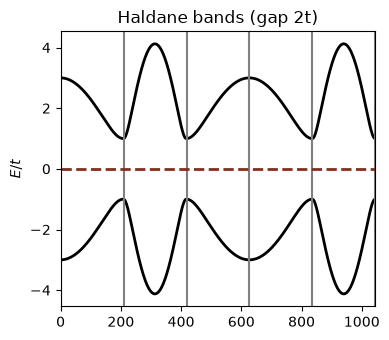

In [8]:
tb_bulk = make_tb(haldane, molecule=False)
evals, evecs, klabels = tb_bulk.solve_alongpath()
plt.figure(figsize=(4, 3.5))
plt.plot(evals, 'k', lw=2)
for k in klabels:
    plt.axvline(k, color='grey')
plt.axhline(0, ls='--', color='#852D1F', lw=2)
plt.xlim(klabels[0], klabels[-1]); plt.ylabel(r'$E/t$'); plt.title('Haldane bands (gap 2t)')
plt.tight_layout()

In [9]:
R_x = np.arange(-4, 5, 1)
R_list = [[i, j] for i in R_x for j in R_x]
df_bulk, _ = QGT_from_bonding(haldane, molecule=False, R_list=R_list, nk=100)
print('sum C_imag =', df_bulk.C_imag.sum(), '(truncated at |R| <= 4; -> +1)')

# how the sum grows with the cutoff
rmax = df_bulk[['R1x', 'R1y', 'R2x', 'R2y']].abs().max(axis=1)
print(pd.Series({r: df_bulk.C_imag[rmax <= r].sum() for r in range(5)}, name='C(|R| <= r)'))


  0%|          | 0/81 [00:00<?, ?it/s]


  1%|          | 1/81 [00:10<14:05, 10.57s/it]


  2%|▏         | 2/81 [00:10<05:57,  4.52s/it]


  4%|▎         | 3/81 [00:11<03:23,  2.61s/it]


  5%|▍         | 4/81 [00:11<02:11,  1.71s/it]

...


 96%|█████████▋| 78/81 [00:23<00:00,  7.00it/s]


 99%|█████████▉| 80/81 [00:23<00:00,  8.05it/s]


100%|██████████| 81/81 [00:24<00:00,  8.40it/s]


100%|██████████| 81/81 [00:24<00:00,  3.36it/s]

sum C_imag = 0.8719663670084474 (truncated at |R| <= 4; -> +1)
0    0.000000
1    0.557519
2    0.629385
3    0.824449
4    0.871966
Name: C(|R| <= r), dtype: float64


## 7. Spectra

In [10]:
EGRID = np.linspace(0, 12, 12001)
ETA = .075                                   # Gaussian sigma (t), display only
Q_SCALE = A_CELL / (2 * np.pi)


def finite_lines(my_model):
    # transition energies and line weights of an open sample
    pos = my_model.get_orb_vecs(cartesian=True)
    ev, U = np.linalg.eigh(my_model.hamiltonian()); no = my_model.norb // 2
    Uo, Ue = U[:, :no], U[:, no:]
    rx = Uo.conj().T @ (pos[:, 0, None] * Ue)
    ry = Uo.conj().T @ (pos[:, 1, None] * Ue)
    de = ev[no:][None, :] - ev[:no][:, None]
    w = -4 * np.pi / (no * A_CELL) * (rx * ry.conj()).imag
    assert abs(w.sum()) < 2e-11                  # open sample: sum = 0
    return de.ravel(), w.ravel(), ev, U


def bulk_lines(my_model, nk=480):
    # Bloch version, H(k) and dH/dk from the natural-embedding hopping table
    _, H = make_ham_func(my_model)
    A = np.array(my_model.get_lat_vecs()); tau = my_model.get_orb_vecs(cartesian=True)
    f = np.arange(nk) / nk
    k = np.array(np.meshgrid(f, f, indexing='ij')).reshape(2, -1).T @ (2 * np.pi * np.linalg.inv(A).T)
    hk = np.zeros((len(k), 2, 2), complex); hx = hk.copy(); hy = hk.copy()
    for i in range(2):
        for j in range(2):
            for t_, dx, dy in H[i][j]:
                v = complex(t_) * np.exp(1j * (k[:, 0] * dx + k[:, 1] * dy))
                hk[:, i, j] += v;          hk[:, j, i] += v.conj()
                hx[:, i, j] += 1j * dx * v; hx[:, j, i] += (1j * dx * v).conj()
                hy[:, i, j] += 1j * dy * v; hy[:, j, i] += (1j * dy * v).conj()
    ev, U = np.linalg.eigh(hk); uo = U[:, :, 0]; ue = U[:, :, 1]; de = ev[:, 1] - ev[:, 0]
    ax_ = np.einsum('ka,kab,kb->k', ue.conj(), hx, uo) / (-de)
    ay_ = np.einsum('ka,kab,kb->k', ue.conj(), hy, uo) / (-de)
    w = -4 * np.pi / A_CELL * (ax_.conj() * ay_).imag / len(k)
    # independent check: gauge-invariant plaquette (Fukui-Hatsugai) Chern number
    up = (uo * np.exp(1j * (k @ tau.T))).reshape(nk, nk, 2)
    lx = np.sum(up.conj() * np.roll(up, -1, axis=0), axis=-1)
    ly = np.sum(up.conj() * np.roll(up, -1, axis=1), axis=-1)
    C_fhs = -np.angle(lx * np.roll(ly, -1, axis=0) * np.roll(lx, -1, axis=1).conj() * ly.conj()).sum() / (2 * np.pi)
    assert abs(C_fhs - 1) < 1e-10 and abs(w.sum() - C_fhs) < 1e-6
    return de, w


def broaden(de, w, eta=ETA, grid=EGRID):
    # linear deposit on the grid, then a reflected Gaussian at E = 0 (area preserving)
    dx = grid[1] - grid[0]; p = de / dx; lo = np.floor(p).astype(int); f = p - lo
    hist = (np.bincount(lo, weights=w * (1 - f), minlength=len(grid)) +
            np.bincount(lo + 1, weights=w * f, minlength=len(grid))) / dx
    return gaussian_filter1d(hist, eta / dx, mode='mirror')


def qcurve(de, w):
    return Q_SCALE * broaden(de, w)          # -2 Im Qxy(E) per electron, a^2/t

NameError: name 'OUT' is not defined

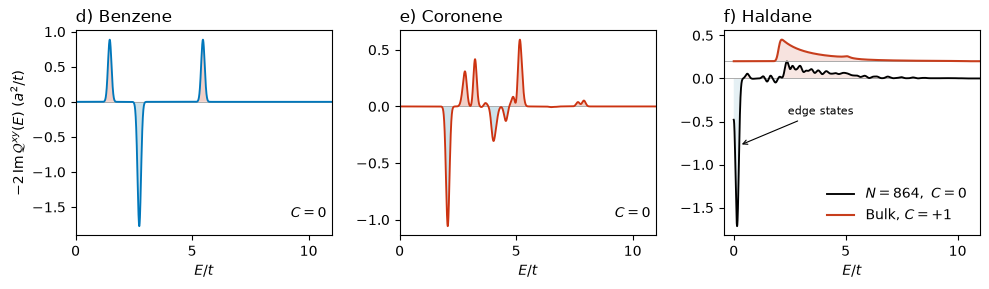

In [11]:
RED, BLUE = '#C73E1D', '#2E86AB'             # positive / negative contributions

#the four spectra: benzene, coronene, 864-site flake (open) and the periodic bulk
curves = {}
for name, my_model in [('benzene', benzene), ('coronene', coronene), ('flake864', flake864)]:
    de, w, _, _ = finite_lines(my_model)
    curves[name] = qcurve(de, w)
curves['bulk'] = qcurve(*bulk_lines(haldane, nk=480))


def sign_fill(ax, y, alpha):
    ax.fill_between(EGRID, y, 0, where=y >= 0, interpolate=True, color=RED, alpha=alpha, lw=0)
    ax.fill_between(EGRID, y, 0, where=y <= 0, interpolate=True, color=BLUE, alpha=alpha, lw=0)


fig, axs = plt.subplots(1, 3, figsize=(10, 3))
for j, (name, color) in enumerate(zip(['benzene', 'coronene', 'flake864'], ['#0077bb', '#cc3311', 'black'])):
    ax = axs[j]; ax.axhline(0, color='.65', lw=.65)
    sign_fill(ax, curves[name], .12 if j == 2 else .24)
    ax.plot(EGRID, curves[name], color=color, lw=1.35, label=r'$N=864,\ C=0$' if j == 2 else None)
    ax.set_xlim(0, 11); ax.set_xticks([0, 5, 10]); ax.set_xlabel(r'$E/t$')
    ax.set_title(['d) Benzene', 'e) Coronene', 'f) Haldane'][j], loc='left')
    if j < 2:
        ax.text(.98, .07, r'$C=0$', transform=ax.transAxes, ha='right', va='bottom')
axs[0].set_ylabel(r'$-2\,\mathrm{Im}\,\mathcal{Q}^{xy}(E)\ (a^2/t)$')
BULK_OFFSET = 0.2                            # manuscript: 'periodic bulk (red, offset)'
axs[2].fill_between(EGRID, BULK_OFFSET + curves['bulk'], BULK_OFFSET, color=RED, alpha=.14, lw=0)
axs[2].axhline(BULK_OFFSET, color='.65', lw=.65)
axs[2].plot(EGRID, BULK_OFFSET + curves['bulk'], color=RED, lw=1.5, label=r'Bulk, $C=+1$')
axs[2].set_xlim(-.45, 11); axs[2].legend(frameon=False, loc='lower right')
# arrow to the right flank of the low-energy trough (render.py)
c = curves['flake864']
trough = np.flatnonzero(EGRID < .75)[np.argmin(c[EGRID < .75])]
flank = np.flatnonzero((EGRID >= EGRID[trough]) & (EGRID < .75))
edge_idx = flank[np.argmin(abs(c[flank] - .45 * c[trough]))]
axs[2].annotate('edge states', xy=(EGRID[edge_idx], c[edge_idx]), xytext=(.25, .59),
                textcoords='axes fraction', fontsize=8, arrowprops=dict(arrowstyle='->', lw=.8))
plt.tight_layout()
fig.savefig(OUT / 'fig4_def_spectra.png', dpi=200, facecolor='white')

NameError: name 'OUT' is not defined

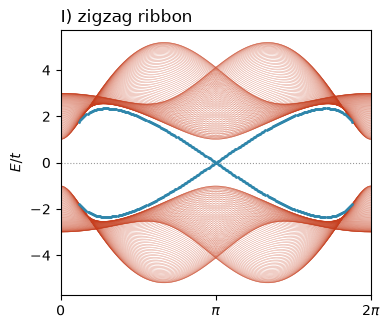

In [12]:
ribbon = haldane.cut_piece(100, 1, glue_edges=False)     # finite along a2, periodic along a1
k_red = np.linspace(0, 1, 301)                           # k * sqrt3 a / 2pi
E_rib, edge_w = [], []
chain = np.repeat(np.arange(100), 2)                     # chain index of each orbital
near_edge = (chain < 5) | (chain >= 95)
for k in k_red:
    e, v = np.linalg.eigh(ribbon.hamiltonian(np.array([[k]]))[0])
    E_rib.append(e); edge_w.append(np.sum(abs(v[near_edge]) ** 2, axis=0))
E_rib, edge_w = np.array(E_rib), np.array(edge_w)

fig, ax = plt.subplots(figsize=(4, 3.4))
for n in range(ribbon.norb):
    ax.plot(2 * np.pi * k_red, E_rib[:, n], color=RED, lw=.3, alpha=.6)
ax.scatter(np.repeat(2 * np.pi * k_red, ribbon.norb)[edge_w.ravel() > .5],
           E_rib.ravel()[edge_w.ravel() > .5], s=1, color=BLUE, zorder=3)
ax.axhline(0, color='.6', ls=':', lw=.8)
ax.set_xticks([0, np.pi, 2 * np.pi], ['0', r'$\pi$', r'$2\pi$']); ax.set_ylabel(r'$E/t$')
ax.set_xlim(0, 2 * np.pi); ax.set_title('I) zigzag ribbon', loc='left')
plt.tight_layout()
fig.savefig(OUT / 'fig4_i_ribbon.png', dpi=200, facecolor='white')

## 9. Compensating fluctuations near the boundary 

In [13]:
def site_marker_from_pos(my_model):
    # Fig. 4 marker M_i = 4 pi Im (P x P y P)_ii from the pythtb model (cross-check)
    pos = my_model.get_orb_vecs(cartesian=True); pos = pos - pos.mean(axis=0)
    ev, U = np.linalg.eigh(my_model.hamiltonian()); Uo = U[:, :my_model.norb // 2]
    P = Uo @ Uo.conj().T
    return 4 * np.pi * np.imag(np.diag(P @ np.diag(pos[:, 0]) @ P @ np.diag(pos[:, 1]) @ P))


def windowed_marker(my_model, window):
    # M_i(W) for the transitions with window(E_m - E_n) True; returns (M_W, centred positions)
    pos = my_model.get_orb_vecs(cartesian=True)
    pos = pos - pos.mean(axis=0)
    ev, U = np.linalg.eigh(my_model.hamiltonian()); no = my_model.norb // 2
    Uo, Ue = U[:, :no], U[:, no:]
    X = Uo.conj().T @ (pos[:, 0, None] * Ue)                 # x_nm   (occ x emp)
    Y = Ue.conj().T @ (pos[:, 1, None] * Uo)                 # y_mn'  (emp x occ)
    A = window(ev[no:][None, :] - ev[:no][:, None]).astype(float)
    K = (A * X) @ Y + X @ (A.T * Y)                          # both halves of the 1/2[...] weight
    return -2 * np.pi * np.imag(np.einsum('in,nk,ik->i', Uo, K, Uo.conj())), pos


def auto_window(curve, frac=0.1):
    # contiguous range around the deepest negative peak where curve <= frac * peak height
    k = np.argmin(curve); thr = frac * curve[k]
    lo = k
    while lo > 0 and curve[lo - 1] <= thr:
        lo -= 1
    hi = k
    while hi < len(curve) - 1 and curve[hi + 1] <= thr:
        hi += 1
    return EGRID[lo], EGRID[hi], EGRID[k], curve[k]


SYSTEMS = {'Benzene': benzene, 'Coronene': coronene, '96-site flake': flake96, '864-site flake': flake864}
comp = {}
for name, my_model in SYSTEMS.items():
    curve = qcurve(*finite_lines(my_model)[:2])              # the Fig. 4(d-f) spectrum
    lo, hi, e_peak, h_peak = auto_window(curve)
    inside = lambda e: (e >= lo) & (e <= hi)
    M_in, pos = windowed_marker(my_model, inside)
    M_out, _ = windowed_marker(my_model, lambda e: ~inside(e))
    assert np.abs(M_in + M_out - site_marker_from_pos(my_model)).max() < 1e-8   # splits the Fig. 4 marker
    comp[name] = dict(pos=pos, curve=curve, window=(lo, hi),
                      c_in=M_in / A_CELL, c_out=M_out / A_CELL,
                      area_in=M_in.sum() / (2 * np.pi * (my_model.norb // 2)))
    print(f'{name:15s} peak {h_peak:+.2f} a^2/t at E = {e_peak:.3f} t -> window [{lo:.3f}, {hi:.3f}] t, '
          f'area {comp[name]["area_in"]:+.3f} a^2;  sum c_i: window {comp[name]["c_in"].sum():+.2f}, '
          f'rest {comp[name]["c_out"].sum():+.2f}')

Benzene         peak -1.77 a^2/t at E = 2.732 t -> window [2.572, 2.892] t, area -0.333 a^2;  sum c_i: window -2.42, rest +2.42
Coronene        peak -1.06 a^2/t at E = 2.064 t -> window [1.904, 2.224] t, area -0.199 a^2;  sum c_i: window -5.77, rest +5.77
96-site flake   peak -1.21 a^2/t at E = 0.901 t -> window [0.741, 1.062] t, area -0.227 a^2;  sum c_i: window -26.32, rest +26.32


864-site flake  peak -1.71 a^2/t at E = 0.149 t -> window [0.000, 0.309] t, area -0.322 a^2;  sum c_i: window -336.62, rest +336.62


## 10. Bond- and fluctuation-resolved quantum metric (Fig. S3)

Every orbital is one carbon $p_z$, so orbital = atom. Lengths in units of the C–C bond $a$; Tr g in
$a^2$ per electron (× 2.0164 for Å², $a$ = 1.42 Å).


### 10.1 Create array with all hopping information

In [15]:
import itertools
from types import SimpleNamespace
A_BOND_ANGSTROM = 1.42                     # C-C bond, for the Å^2 columns

def hopping_arrays(my_model, name):
    #Create array with all hopping information (2D)
    M = SimpleNamespace(name=name)
    M.lat = np.array(my_model.get_lat_vecs())                           # lattice vectors (rows)
    M.orb_red = np.array(my_model.orb_vecs)
    hoppings = [(hop['amplitude'], hop['from_orbital'], hop['to_orbital'], hop.get('lattice_vector', [0, 0]))
                for hop in my_model.hoppings]
    M.orb_pos = M.orb_red @ M.lat                                       # orbital centres, cartesian
    M.norb = len(M.orb_pos)
    M.onsite = np.real(np.array(my_model._site_energies, dtype=complex))

    hop_from, hop_to, hop_R, hop_t = [], [], [], []
    for t, i, j, j_image in hoppings:
        j_image = np.array(j_image, dtype=int)
        hop_from += [i, j];  hop_to += [j, i]                           # i -> j+R  and its partner  j -> i-R
        hop_R += [j_image, -j_image]
        hop_t += [t, np.conj(t)]
    M.hop_from = np.array(hop_from); M.hop_to = np.array(hop_to)
    M.hop_R = np.array(hop_R); M.hop_t = np.array(hop_t, dtype=complex)
    M.hop_disp = (M.hop_R + M.orb_red[M.hop_to] - M.orb_red[M.hop_from]) @ M.lat   # d = R + tau_j - tau_i
    M.hop_vel = 1j * M.hop_disp * M.hop_t[:, None]                      # v^mu = i d^mu t   (nhop x 2)

    #Which atom each orbital belongs to: every pz orbital is its own carbon, in the home cell
    M.atom_pos = M.orb_pos.copy()
    M.species = ['C'] * M.norb
    M.orb_atom = np.arange(M.norb)
    M.orb_cell = np.zeros((M.norb, 2), dtype=int)
    M.periodic = bool(np.any(M.hop_R != 0))
    print(name, ':', M.norb, "orbitals,", len(M.hop_t), "directed hoppings,  longest hop %.2f a"
          % np.linalg.norm(M.hop_disp, axis=1).max())
    return M

### 10.2 Hamiltonian and velocity on the k-mesh

In [16]:
def ham_func(M, kpts, hop_mask=None):
    #H(k) and v_mu(k) = dH/dk_mu for an array of cartesian k-points (shape nk x 2)
    sel = np.ones(len(M.hop_t), bool) if hop_mask is None else hop_mask
    phase = np.exp(1j * kpts @ M.hop_disp[sel].T) * M.hop_t[sel]       # (nk, nhop): t e^{ik.d}
    to_matrix = np.zeros((sel.sum(), M.norb * M.norb))                 # hops -> matrix element (i, j)
    to_matrix[np.arange(sel.sum()), M.hop_from[sel] * M.norb + M.hop_to[sel]] = 1
    H = (phase @ to_matrix).reshape(-1, M.norb, M.norb)
    V = np.stack([((1j * M.hop_disp[sel, c] * phase) @ to_matrix).reshape(-1, M.norb, M.norb) for c in range(2)])
    if hop_mask is None:
        H = H + np.diag(M.onsite)
    return H, V


def k_mesh(M, nk):
    M.nk = nk if M.periodic else 1                                      # a molecule: one k-point
    recip = 2 * np.pi * np.linalg.inv(M.lat).T
    g = (np.arange(M.nk) + 0.5) / M.nk
    k_frac = np.array(np.meshgrid(g, g, indexing="ij")).reshape(2, -1).T
    M.recip = recip
    M.kSpan = k_frac @ recip                                            # cartesian k, nk^2 points
    M.H_k, M.V_k = ham_func(M, M.kSpan)
    M.E_k, M.U_k = np.linalg.eigh(M.H_k)                                # U_k[k, orbital, band]

    mu = 0.0                                                            # half filling
    M.occ = int(np.bincount((M.E_k < mu).sum(1)).argmax())              # occupied bands
    M.vbm, M.cbm = M.E_k[:, M.occ - 1].max(), M.E_k[:, M.occ].min()
    M.mu0 = 0.5 * (M.vbm + M.cbm)
    print("   nk %d, occ %d, VBM %.4f  CBM %.4f  gap %.4f t" % (M.nk, M.occ, M.vbm, M.cbm, M.cbm - M.vbm))
    assert M.cbm > M.vbm, "no gap: occupied/empty split is not defined"
    return M

### 10.3 The k-space sums

In [17]:
def kspace_sums(M):
    #Intra-atomic hops: start site == end site (none here: every orbital is its own atom)
    M.start_atom, M.start_cell = M.orb_atom[M.hop_from], M.orb_cell[M.hop_from]
    M.end_atom, M.end_cell = M.orb_atom[M.hop_to], M.hop_R + M.orb_cell[M.hop_to]
    intra = (M.start_atom == M.end_atom) & (M.start_cell == M.end_cell).all(1)
    Vintra_k = ham_func(M, M.kSpan, hop_mask=intra)[1] if intra.any() else np.zeros_like(M.V_k)

    #k-space sums
    Uo, Ue = M.U_k[:, :, :M.occ], M.U_k[:, :, M.occ:]
    w = 1.0 / (M.E_k[:, None, M.occ:] - M.E_k[:, :M.occ, None]) ** 2  # w[k, i occ, j emp]
    denom = len(M.kSpan) * M.occ
    M.kspace = {key: np.zeros(2, complex) for key in ("T", "S_AD", "S_BC", "S_ADBC")}
    for c in range(2):
        v  = np.einsum("kai,kab,kbj->kij", Uo.conj(), M.V_k[c], Ue)     # <i|v|j>, all hops
        vi = np.einsum("kai,kab,kbj->kij", Uo.conj(), Vintra_k[c], Ue)  # <i|v|j>, intra-atomic hops only
        M.kspace["T"][c]      = (w * v  * v.conj()).sum()  / denom
        M.kspace["S_AD"][c]   = (w * vi * v.conj()).sum()  / denom
        M.kspace["S_BC"][c]   = (w * v  * vi.conj()).sum() / denom
        M.kspace["S_ADBC"][c] = (w * vi * vi.conj()).sum() / denom
    print("   total quantum metric  xx %.5f  yy %.5f   Tr g = %.5f a^2 per electron"
          % (*M.kspace["T"].real, M.kspace["T"].real.sum()))
    return M

### 10.4 Bond-resolved quantum metric (Eq. 1)

$\mathrm{Tr}\,g = \frac1{2N_e}\sum_{\alpha\beta}|\rho_{\alpha\beta}|^2|\mathbf R_{\alpha\beta}|^2$: every bond from an orbital of the home cell, with
`rho[o, o', R]` = ⟨o, cell R | P | o', home cell⟩ from the same Fourier transform as §10.5 (all occupied
bands, no time factor). Bonds of the same length form one row of the histogram (Fig. S3 D–F).
The bond index is reported as $b = 4|\rho|^2$ (closed-shell Mayer/Wiberg, as in `bondorder_tb.py`).

In [18]:
def density_matrix(M, bands, gt, cells):
    #rho[o, o', cell] = <o, cell R | U g U^dagger | o', home cell>  (Fourier transform over the mesh)
    orb_phase = np.exp(1j * M.kSpan @ M.orb_pos.T)                      # e^{ik.tau_o}
    P = orb_phase[:, :, None] * orb_phase.conj()[:, None, :]            # e^{ik(tau_o - tau_o')}
    Ub = M.U_k[:, :, bands]
    rho_k = np.einsum("kai,ki,kbi->kab", Ub, gt, Ub.conj()) * P         # U g U^dagger
    F = np.fft.ifftn(rho_k.reshape(M.nk, M.nk, M.norb, M.norb), axes=(0, 1))   # (1/N) sum_k e^{ik.R}
    shift_phase = np.exp(1j * np.pi * cells.sum(1) / M.nk)              # half-step mesh shift
    return (F[tuple((cells % M.nk).T)] * shift_phase[:, None, None]).transpose(1, 2, 0)


def bond_resolved(M):
    #all cells the mesh resolves without aliasing (one cell for a molecule)
    n = (M.nk - 1) // 2
    cells = np.array(list(itertools.product(range(-n, n + 1), repeat=2)))
    rho = density_matrix(M, slice(0, M.occ), np.ones((len(M.kSpan), M.occ)), cells)

    #every bond o' (home cell) -> o (cell R): |rho|^2 |R|^2 / (2 occ)
    rows = []
    for o2 in range(M.norb):
        for o in range(M.norb):
            disp = M.orb_pos[o] + cells @ M.lat - M.orb_pos[o2]
            dist = np.linalg.norm(disp, axis=1)
            for n_cell in np.where(dist > 1e-6)[0]:
                r = rho[o, o2, n_cell]
                rows.append([o2, o, *cells[n_cell], dist[n_cell], 4 * abs(r) ** 2,
                             abs(r) ** 2 * dist[n_cell] ** 2 / (2 * M.occ)])
    bonds = pd.DataFrame(rows, columns=['from', 'to', 'R1', 'R2', 'distance', 'bond_index', 'trg'])
    M.trg_bonds = bonds['trg'].sum()

    #bonds of the same length -> one shell (each bond is listed once from each end)
    bonds['shell'] = bonds['distance'].round(2)
    shells = bonds.groupby('shell').agg(bonds=('trg', 'size'), bond_index=('bond_index', 'mean'),
                                        trg=('trg', 'sum')).reset_index()
    shells['bonds'] = shells['bonds'] / 2
    shells['trg_A2'] = shells['trg'] * A_BOND_ANGSTROM ** 2
    shells['pct_of_trg'] = 100 * shells['trg'] / M.trg_bonds
    M.bonds = bonds
    M.shells = shells.sort_values('pct_of_trg', ascending=False).reset_index(drop=True)
    print("   bond-resolved Tr g = %.5f a^2  (k-space %.5f)" % (M.trg_bonds, M.kspace['T'].real.sum()))
    return M

### 10.5 Enumerate the 2- and 3-center shared-site terms, and evaluate them in real space

As in `Fig2_minimal.ipynb` §6–7: a term with a site shared between the two hops is evaluated as

$$X = \int_0^\infty t\,dt\;\; v_{AD}\;\rho_\mathrm{emp}(t)_{DB}\;v_{BC}\;\rho_\mathrm{occ}(t)_{CA},\qquad
\frac{1}{(E_j-E_i)^2} = \int_0^\infty t\,e^{-t(E_j-\mu_0)}\,e^{-t(\mu_0-E_i)}\,dt ,$$

with $A$ in the home cell (value per cell, per electron).

In [19]:
def canonicalize(combo):
    mapping = {}
    next_label = ord('a')
    result = []
    for x in combo:
        if x not in mapping:
            mapping[x] = chr(next_label)
            next_label += 1
        result.append(mapping[x])
    return ''.join(result)

all_patterns = sorted({canonicalize(p) for p in itertools.product(range(4), repeat=4)})   # the 15 patterns
def equality_code(A, D, B, C):
    eq = [A == D, A == B, A == C, D == B, D == C, B == C]
    return sum(np.asarray(e).astype(int) << n for n, e in enumerate(eq))
code_to_pattern = {equality_code(*p): p for p in all_patterns}

CLASS = {'abba': '2-center polarization', 'abab': '2-center transfer',
         'abbc': '3-center', 'abcb': '3-center', 'abac': '3-center', 'abca': '3-center', 'abcd': '4-center'}
def pattern_class(p):
    return CLASS.get(p, 'other (A=D or B=C)')

def site_id(atom, cell):
    #one integer per (atom, cell), so sites can be compared with ==
    cell = np.asarray(cell) + 512
    return (np.asarray(atom) * 1024 + cell[..., 0]) * 1024 + cell[..., 1]

coincidence_types = [("A=B", "start", "start"), ("A=C", "start", "end"),
                     ("D=B", "end", "start"),   ("D=C", "end", "end")]

def shared_site_terms(M, chunk=200000):
    #Yield chunks of shared-site terms: (h1, h2, RB, code); every term exactly once
    for n_type, (name, side1, side2) in enumerate(coincidence_types):
        for alpha in range(len(M.atom_pos)):
            h1_all = np.where((M.start_atom if side1 == "start" else M.end_atom) == alpha)[0]
            h2     = np.where((M.start_atom if side2 == "start" else M.end_atom) == alpha)[0]
            step = max(1, chunk // max(len(h2), 1))
            for s in range(0, len(h1_all), step):
                h1 = np.repeat(h1_all[s:s + step], len(h2))             # all (h1, h2) pairs of this chunk
                h2p = np.tile(h2, len(h1_all[s:s + step]))
                a, d, hD = M.hop_from[h1], M.hop_to[h1], M.hop_R[h1]
                b, c, hC = M.hop_from[h2p], M.hop_to[h2p], M.hop_R[h2p]
                if name == "A=B":   RB = M.orb_cell[a] - M.orb_cell[b]
                elif name == "A=C": RB = M.orb_cell[a] - M.orb_cell[c] - hC
                elif name == "D=B": RB = hD + M.orb_cell[d] - M.orb_cell[b]
                else:               RB = hD + M.orb_cell[d] - M.orb_cell[c] - hC
                A = site_id(M.orb_atom[a], M.orb_cell[a])
                D = site_id(M.orb_atom[d], hD + M.orb_cell[d])
                B = site_id(M.orb_atom[b], RB + M.orb_cell[b])
                C = site_id(M.orb_atom[c], RB + hC + M.orb_cell[c])
                earlier = [A == B, A == C, D == B, D == C][:n_type]  # coincidences of earlier types
                keep = ~np.any(earlier, axis=0) if earlier else np.ones(len(h1), bool)
                yield h1[keep], h2p[keep], RB[keep], equality_code(A, D, B, C)[keep]


def time_grid(M, t_step=0.3):
    #Time grid for 1/dE^2 = int t e^{-t dE} dt   (log spaced: t = e^s, dt = t ds)
    Wmax = M.E_k.max() - M.E_k.min()
    gap_direct = (M.E_k[:, M.occ] - M.E_k[:, M.occ - 1]).min()
    s = np.arange(np.log(1e-3 / Wmax), np.log(60.0 / gap_direct) + t_step, t_step)
    M.t_grid = np.exp(s)
    M.t_weights = t_step * M.t_grid ** 2                                # t dt = t^2 ds
    dE_test = np.linspace(M.cbm - M.vbm, Wmax, 400)
    quad_err = np.abs((M.t_weights * np.exp(-np.outer(dE_test, M.t_grid))).sum(1) * dE_test ** 2 - 1).max()
    print("   %d time points,  quadrature max relative error %.1e" % (len(M.t_grid), quad_err))
    return M


def time_density_matrices(M, cells):
    #rho_occ[t, o, o', cell] and rho_emp[t, o, o', cell] on the cells the terms need
    assert np.abs(cells).max() <= (M.nk - 1) // 2, f"k-mesh too small: need nk > {2 * np.abs(cells).max()}"
    rho_occ = np.zeros((len(M.t_grid), M.norb, M.norb, len(cells)), complex)
    rho_emp = np.zeros_like(rho_occ)
    for it, t in enumerate(M.t_grid):
        rho_occ[it] = density_matrix(M, slice(0, M.occ), np.exp(+t * (M.E_k[:, :M.occ] - M.mu0)), cells)
        rho_emp[it] = density_matrix(M, slice(M.occ, None), np.exp(-t * (M.E_k[:, M.occ:] - M.mu0)), cells)
    return rho_occ, rho_emp


def evaluate_terms(M, terms, rho_occ, rho_emp, cell_index):
    #Evaluate every term and add it to its motif; returns pattern sums, A=D / B=C sums and the motif rows
    pattern_sum = {p: np.zeros(2, complex) for p in all_patterns}
    enum_AD = np.zeros(2, complex); enum_BC = np.zeros(2, complex); enum_ADBC = np.zeros(2, complex)
    motif_rows = []
    for h1, h2, RB, code in terms:
        if len(h1) == 0:
            continue
        a, d, hD = M.hop_from[h1], M.hop_to[h1], M.hop_R[h1]
        b, c, hC = M.hop_from[h2], M.hop_to[h2], M.hop_R[h2]
        i1 = np.array([cell_index[tuple(R)] for R in hD - RB])
        i2 = np.array([cell_index[tuple(R)] for R in RB + hC])
        K = np.einsum("t,tp,tp->p", M.t_weights, rho_emp[:, d, b, i1], rho_occ[:, c, a, i2])   # int t dt rho_emp rho_occ
        value = M.hop_vel[h1] * M.hop_vel[h2] * K[:, None] / M.occ     # (terms, 2): xx, yy
        for cd in np.unique(code):
            pattern_sum[code_to_pattern[cd]] += value[code == cd].sum(0)
        AD, BC = (code & 1) > 0, (code & 32) > 0                        # bit 0: A=D, bit 5: B=C
        enum_AD += value[AD].sum(0); enum_BC += value[BC].sum(0); enum_ADBC += value[AD & BC].sum(0)
        site_cells = np.stack([M.orb_cell[a], hD + M.orb_cell[d], RB + M.orb_cell[b], RB + hC + M.orb_cell[c]], 1)
        site_cells = site_cells - site_cells[:, :1]                     # cells relative to A
        key = np.concatenate([code[:, None], np.stack([M.orb_atom[a], M.orb_atom[d], M.orb_atom[b], M.orb_atom[c]], 1),
                              site_cells.reshape(len(code), -1)], 1)
        uk, inv = np.unique(key, axis=0, return_inverse=True)
        summed = np.zeros((len(uk), 2)); np.add.at(summed, inv.ravel(), value.real)
        motif_rows.append(np.concatenate([uk, summed], 1))
    return pattern_sum, enum_AD, enum_BC, enum_ADBC, motif_rows


def shared_site_fluctuations(M):
    terms = list(shared_site_terms(M))
    print("   %d shared-site terms" % sum(len(t[0]) for t in terms))
    needed = set()
    for h1, h2, RB, code in terms:
        needed.update(map(tuple, np.unique(M.hop_R[h1] - RB, axis=0)))
        needed.update(map(tuple, np.unique(RB + M.hop_R[h2], axis=0)))
    cells = np.array(sorted(needed))
    cell_index = {tuple(R): n for n, R in enumerate(cells)}
    rho_occ, rho_emp = time_density_matrices(M, cells)
    M.pattern_sum, M.enum_AD, M.enum_BC, M.enum_ADBC, M.motif_rows = evaluate_terms(M, terms, rho_occ, rho_emp, cell_index)
    return M

### 10.6 The remaining patterns from the k-space sums, and the tables

    aabb = S_ADBC − (enumerated terms with A=D and B=C)
    aabc = S_AD   − (enumerated terms with A=D) − aabb
    abcc = S_BC   − (enumerated terms with B=C) − aabb
    abcd (4-center) = T − all other patterns

In [20]:
def pattern_tables(M):
    QM = dict(M.pattern_sum)
    QM['aabb'] = M.kspace['S_ADBC'] - M.enum_ADBC
    QM['aabc'] = M.kspace['S_AD'] - M.enum_AD - QM['aabb']
    QM['abcc'] = M.kspace['S_BC'] - M.enum_BC - QM['aabb']
    QM['abcd'] = M.kspace['T'] - sum(v for p, v in QM.items() if p != 'abcd')
    print("   sum of patterns %.6f = k-space total %.6f,  largest imaginary part %.1e"
          % (sum(QM.values()).real.sum(), M.kspace['T'].real.sum(), max(abs(v.imag).max() for v in QM.values())))
    M.QM = QM
    M.patterns_df = pd.DataFrame([dict(pattern=p, cls=pattern_class(p), xx=QM[p][0].real, yy=QM[p][1].real,
                                       trace=QM[p].real.sum()) for p in all_patterns])
    classes_df = M.patterns_df.groupby('cls')[['xx', 'yy', 'trace']].sum()
    classes_df = classes_df.reindex(['2-center polarization', '2-center transfer', '3-center', '4-center', 'other (A=D or B=C)'])
    classes_df.loc['total, Tr g'] = classes_df.sum()
    classes_df['trace_A2'] = classes_df['trace'] * A_BOND_ANGSTROM ** 2
    M.classes_df = classes_df
    return M

### 10.7 Group motifs into fluctuations

One fluctuation = all motifs with the same pattern, the same kind of site at A, D, B, C, and the same six
distances. A loop and the same loop read backwards (C, B, D, A) count as one fluctuation. `copies` = how
many motifs were added up. Distances: `d12_excite` = |AD|, `d23_virtual` = |DB|, `d34_decay` = |BC|,
`d14_filled` = |AC|, `d13` = |AB|, `d24` = |DC|.

In [21]:
greek = {'a': 'α', 'b': 'β', 'c': 'γ', 'd': 'δ'}

def site_kinds(M):
    #Kind of site of each atom: same species + same distances to its 12 nearest neighbours = same kind
    nearby_cells = list(itertools.product(range(-2, 3), repeat=2)) if M.periodic else [(0, 0)]
    fingerprint = []
    for i in range(len(M.atom_pos)):
        dists = []
        for j in range(len(M.atom_pos)):
            for R in nearby_cells:
                dist = np.linalg.norm(M.atom_pos[j] + np.array(R) @ M.lat - M.atom_pos[i])
                if dist > 1e-6:
                    dists.append(dist)
        fingerprint.append((M.species[i], tuple(np.round(sorted(dists)[:12], 1))))
    site_kind = []
    for i in range(len(M.atom_pos)):
        kinds = []                                  # the different kinds of site of this species
        for f in fingerprint:
            if f[0] == M.species[i] and f not in kinds:
                kinds.append(f)
        if len(kinds) == 1:
            site_kind.append(M.species[i])          # e.g. C
        else:
            site_kind.append(M.species[i] + "abcdefgh"[kinds.index(fingerprint[i])])   # e.g. Ca, Cb
    M.site_kind = site_kind
    return M


def motif_table(M, motif_rows):
    #motif rows -> table with pattern, class, positions of A, D, B, C and the trace
    motifs = pd.DataFrame(np.concatenate(motif_rows), columns=['code', 'A', 'D', 'B', 'C'] +
                          [f'{s}{x}' for s in 'ADBC' for x in 'xy'] + ['xx', 'yy'])
    motifs = motifs.groupby(list(motifs.columns[:-2]), as_index=False)[['xx', 'yy']].sum()   # merge chunks
    motifs['pattern'] = [code_to_pattern[int(c)] for c in motifs['code']]
    motifs['class'] = motifs['pattern'].map(pattern_class)
    motifs['trace'] = motifs[['xx', 'yy']].sum(axis=1)
    for s in 'ADBC':
        cell = motifs[[f'{s}x', f'{s}y']].to_numpy(int)
        motifs[f'pos{s}'] = list(M.atom_pos[motifs[s].astype(int)] + cell @ M.lat)
    return motifs


def fluctuation_key(pattern, kinds, pos):
    #pattern, site kinds and the six distances; a loop and its reverse get the same key
    pairs = [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]            # AD, AB, AC, DB, DC, BC
    d = [np.round(np.linalg.norm(pos[i] - pos[j]), 2) for i, j in pairs]
    forward = (pattern, tuple(kinds), tuple(d))
    #same loop read backwards (C, B, D, A): AD <-> BC, AB <-> DC, AC and DB stay
    backward = (canonicalize(pattern[::-1]), tuple(kinds[::-1]), (d[5], d[4], d[2], d[3], d[1], d[0]))
    return min(forward, backward)


def group_fluctuations(M, motifs, max_distance=None):
    #add up the motifs (rows with pattern, A, D, B, C, posA..posC, trace) of each fluctuation
    total = M.classes_df.loc['total, Tr g', 'trace']
    groups = {}                                     # key -> [value, copies]
    for i, m in motifs.iterrows():
        pos = [m['posA'], m['posD'], m['posB'], m['posC']]
        if max_distance is not None:                # skip motifs with two atoms farther apart than max_distance
            if max(np.linalg.norm(p - q) for p in pos for q in pos) > max_distance + 1e-6:
                continue
        kinds = [M.site_kind[int(m[s])] for s in 'ADBC']
        key = fluctuation_key(m['pattern'], kinds, pos)
        if key not in groups:
            groups[key] = [0.0, 0]
        groups[key][0] += m['trace']
        groups[key][1] += 1

    rows = []
    for (pattern, kinds, d), (value, copies) in groups.items():
        rows.append([''.join(greek[x] for x in pattern), pattern_class(pattern), '-'.join(kinds),
                     d[0], d[3], d[5], d[2], d[1], d[4], copies, value, value / copies, 100 * value / total])
    columns = ['type', 'class', 'sites', 'd12_excite', 'd23_virtual', 'd34_decay', 'd14_filled', 'd13', 'd24',
               'copies', 'value', 'value_per_copy', '% of total']
    df = pd.DataFrame(rows, columns=columns)
    return df.sort_values('value', key=np.abs, ascending=False).reset_index(drop=True)

### 10.8 Largest 4-center fluctuations

As in `Fig2_minimal.ipynb` §12: every pair of hops along short bonds (each hop at most `dmax`), with all four
atoms within `rmax` of each other, evaluated one by one. For a molecule this is every 4-center term, so the
listed fluctuations add up to the whole 4-center class.

In [22]:
def atom_position(M, orbital, cell):
    #cartesian position of the atom of an orbital that sits in lattice cell `cell`
    return M.atom_pos[M.orb_atom[orbital]] + (cell + M.orb_cell[orbital]) @ M.lat


def four_center(M, dmax=1.8, rmax=4.0):
    #hops along short bonds (between two different atoms)
    bond_hops = []
    for h in range(len(M.hop_t)):
        bond = np.linalg.norm(atom_position(M, M.hop_to[h], M.hop_R[h]) - atom_position(M, M.hop_from[h], 0))
        if 0.1 < bond <= dmax:
            bond_hops.append(h)

    #every pair of these hops, at every cell RB where atom B is within rmax of atom A
    h1_all = np.repeat(bond_hops, len(bond_hops))
    h2_all = np.tile(bond_hops, len(bond_hops))
    n = int(np.ceil((rmax + 2 * np.abs(M.orb_pos).max()) * np.linalg.norm(M.recip, axis=1).max() / (2 * np.pi))) if M.periodic else 0
    terms4 = []
    for RB in itertools.product(range(-n, n + 1), repeat=2):
        RB = np.array(RB)
        dist_AB = np.linalg.norm(atom_position(M, M.hop_from[h2_all], RB) - atom_position(M, M.hop_from[h1_all], 0), axis=1)
        near = dist_AB <= rmax
        if near.any():
            h1, h2 = h1_all[near], h2_all[near]
            a, d, hD = M.hop_from[h1], M.hop_to[h1], M.hop_R[h1]
            b, c, hC = M.hop_from[h2], M.hop_to[h2], M.hop_R[h2]
            code = equality_code(site_id(M.orb_atom[a], M.orb_cell[a]), site_id(M.orb_atom[d], hD + M.orb_cell[d]),
                                 site_id(M.orb_atom[b], RB + M.orb_cell[b]), site_id(M.orb_atom[c], RB + hC + M.orb_cell[c]))
            terms4.append((h1, h2, np.tile(RB, (len(h1), 1)), code))
    print("   %d hops on bonds up to %.1f a,  %d terms" % (len(bond_hops), dmax, sum(len(t[0]) for t in terms4)))

    #density matrices on the cells these terms need, then evaluate (as in 10.5)
    needed4 = set()
    for h1, h2, RB, code in terms4:
        needed4.update(map(tuple, np.unique(M.hop_R[h1] - RB, axis=0)))
        needed4.update(map(tuple, np.unique(RB + M.hop_R[h2], axis=0)))
    cells4 = np.array(sorted(needed4))
    cell_index4 = {tuple(R): n for n, R in enumerate(cells4)}
    rho_occ4, rho_emp4 = time_density_matrices(M, cells4)
    motif_rows4 = evaluate_terms(M, terms4, rho_occ4, rho_emp4, cell_index4)[4]
    motifs4 = motif_table(M, motif_rows4)

    #fluctuations, keeping only motifs with all four atoms within rmax
    fluct4_all = group_fluctuations(M, motifs4, max_distance=rmax)
    M.fluct4 = fluct4_all[fluct4_all['class'] == '4-center'].reset_index(drop=True)
    print("   4-center class %.4f;  the fluctuations found here add up to %.4f (%.0f%% of it)"
          % (M.classes_df.loc['4-center', 'trace'], M.fluct4['value'].sum(),
             100 * M.fluct4['value'].sum() / M.classes_df.loc['4-center', 'trace']))
    return M

### 10.9 Run the three models

In [23]:
nk_metric = 48                       # k-mesh for the periodic Haldane model (Tr g converged to 2e-5)
csv_dir = Path('fig4_minimal_output'); csv_dir.mkdir(exist_ok=True)   # where the csv files go
S3 = {}
for name, my_model in [('Haldane', haldane), ('Benzene', benzene), ('Coronene', coronene)]:
    mm = hopping_arrays(my_model, name)
    mm = k_mesh(mm, nk_metric)
    mm = kspace_sums(mm)
    mm = bond_resolved(mm)
    mm = time_grid(mm)
    mm = shared_site_fluctuations(mm)
    mm = pattern_tables(mm)
    mm = site_kinds(mm)
    mm.motifs = motif_table(mm, mm.motif_rows)
    mm.fluct = group_fluctuations(mm, mm.motifs)                 # 2- and 3-center fluctuations
    mm = four_center(mm)
    S3[name] = mm

    #csv files
    tag = name.lower()
    mm.bonds.to_csv(csv_dir / f'bond_metric_bonds_{tag}.csv', index=False)
    mm.shells.to_csv(csv_dir / f'bond_metric_shells_{tag}.csv', index=False)
    mm.classes_df.to_csv(csv_dir / f'metric_classes_{tag}.csv')
    pd.concat([mm.fluct, mm.fluct4]).to_csv(csv_dir / f'top_fluctuations_{tag}.csv', index=False)
    print()

pd.DataFrame({name: S3[name].classes_df['trace_A2'] for name in S3}).round(3)

Haldane : 2 orbitals, 18 directed hoppings,  longest hop 1.73 a
   nk 48, occ 1, VBM -1.0043  CBM 1.0043  gap 2.0085 t
   total quantum metric  xx 0.43004  yy 0.43005   Tr g = 0.86009 a^2 per electron
   bond-resolved Tr g = 0.86009 a^2  (k-space 0.86009)
   44 time points,  quadrature max relative error 3.6e-07
   612 shared-site terms
   sum of patterns 0.860087 = k-space total 0.860087,  largest imaginary part 5.5e-18


   18 hops on bonds up to 1.8 a,  6480 terms


   4-center class 0.4002;  the fluctuations found here add up to 0.2578 (64% of it)

Benzene : 6 orbitals, 24 directed hoppings,  longest hop 1.73 a
   nk 1, occ 3, VBM -0.7321  CBM 0.7321  gap 1.4641 t
   total quantum metric  xx 0.33333  yy 0.33333   Tr g = 0.66667 a^2 per electron
   bond-resolved Tr g = 0.66667 a^2  (k-space 0.66667)
   43 time points,  quadrature max relative error 3.6e-07
   336 shared-site terms
   sum of patterns 0.666667 = k-space total 0.666667,  largest imaginary part 3.0e-17
   24 hops on bonds up to 1.8 a,  576 terms


   4-center class 0.1111;  the fluctuations found here add up to 0.1111 (100% of it)

Coronene : 24 orbitals, 156 directed hoppings,  longest hop 1.73 a
   nk 1, occ 12, VBM -0.7321  CBM 0.7321  gap 1.4641 t
   total quantum metric  xx 0.34533  yy 0.34533   Tr g = 0.69066 a^2 per electron
   bond-resolved Tr g = 0.69066 a^2  (k-space 0.69066)
   44 time points,  quadrature max relative error 3.6e-07
   4008 shared-site terms
   sum of patterns 0.690657 = k-space total 0.690657,  largest imaginary part 5.0e-18


   156 hops on bonds up to 1.8 a,  21156 terms


   4-center class 0.1482;  the fluctuations found here add up to 0.0895 (60% of it)



,Haldane,Benzene,Coronene
cls,,,
2-center polarization,0.772,0.974,0.817
2-center transfer,0.050,0.439,0.126
3-center,0.105,-0.292,0.151
4-center,0.807,0.224,0.299
other (A=D or B=C),0.000,0.000,0.000
"total, Tr g",1.734,1.344,1.393


Haldane
  2-center polarization  αββα  C-C-C-C      |AD| 1.73  |DB| 0.00  |BC| 1.73  |AC| 0.00   +0.02736 x 12 = +0.3283 a^2 (+38.2%)
  2-center transfer      αβαβ  C-C-C-C      |AD| 1.73  |DB| 1.73  |BC| 1.73  |AC| 1.73   +0.00121 x 12 = +0.0145 a^2 (+1.7%)
  3-center               αβγα  C-C-C-C      |AD| 1.73  |DB| 3.00  |BC| 1.73  |AC| 0.00   +0.00141 x 24 = +0.0339 a^2 (+3.9%)
  4-center               αβγδ  C-C-C-C      |AD| 1.73  |DB| 1.00  |BC| 1.73  |AC| 1.00   +0.00524 x 24 = +0.1258 a^2 (+14.6%)
Benzene
  2-center polarization  αββα  C-C-C-C      |AD| 1.73  |DB| 0.00  |BC| 1.73  |AC| 0.00   +0.03018 x 12 = +0.3621 a^2 (+54.3%)
  2-center transfer      αβαβ  C-C-C-C      |AD| 1.73  |DB| 1.73  |BC| 1.73  |AC| 1.73   +0.01529 x 12 = +0.1835 a^2 (+27.5%)
  3-center               αββγ  C-C-C-C      |AD| 1.00  |DB| 0.00  |BC| 1.73  |AC| 1.00   -0.00628 x 24 = -0.1508 a^2 (-22.6%)
  4-center               αβγδ  C-C-C-C      |AD| 1.73  |DB| 2.00  |BC| 1.73  |AC| 2.00   +0.01596 x 12 =

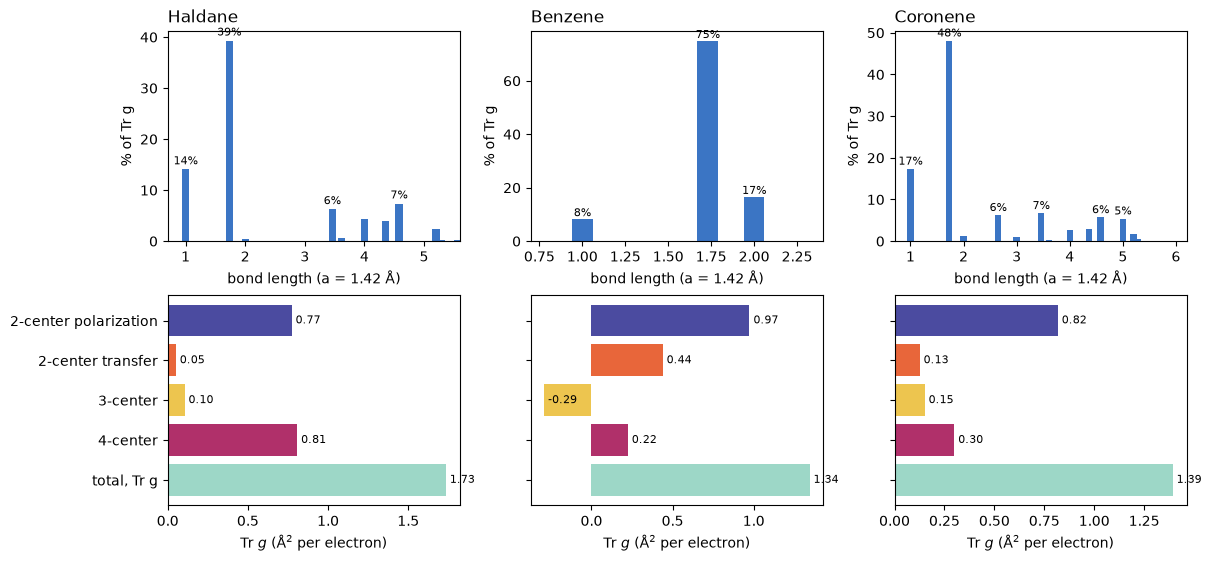

In [24]:
#Bars (Fig. S3 J-L) and share of Tr g by bond length (Fig. S3 D-F)
order = ['2-center polarization', '2-center transfer', '3-center', '4-center', 'total, Tr g']
fig, axs = plt.subplots(2, 3, figsize=(12, 5.5), layout='constrained')
for col, (name, xmax) in enumerate([('Haldane', 5.6), ('Benzene', 2.4), ('Coronene', 6.2)]):
    mm = S3[name]
    ax = axs[0, col]
    sh = mm.shells.sort_values('shell')
    ax.bar(sh['shell'], sh['pct_of_trg'], width=.12, color='#3B75C4')
    for r in sh.itertuples():
        if r.pct_of_trg >= 5:
            ax.text(r.shell, r.pct_of_trg + 1, f'{r.pct_of_trg:.0f}%', ha='center', fontsize=8)
    ax.set_xlim(0.7, xmax); ax.set_ylabel('% of Tr g'); ax.set_title(name, loc='left')
    ax.set_xlabel(f'bond length (a = {A_BOND_ANGSTROM} Å)')

    ax = axs[1, col]
    vals = mm.classes_df.loc[order, 'trace_A2']
    ax.barh(order[::-1], vals[::-1], color=['#9DD7C7', '#B0306A', '#EDC54F', '#E8663A', '#4B4BA0'])
    for i, v in enumerate(vals[::-1]):
        ax.text(v, i, f' {v:.2f}', va='center', fontsize=8)
    ax.set_xlabel(r'Tr $g$ (Å$^2$ per electron)')
    if col > 0:
        ax.set_yticklabels([])
fig.savefig(csv_dir / 'fig_S3_bars.png', dpi=200, facecolor='white')

#Largest fluctuation of each class (Fig. S3 G-I)
for name in S3:
    mm = S3[name]
    allf = pd.concat([mm.fluct, mm.fluct4])
    print(name)
    for cls in ['2-center polarization', '2-center transfer', '3-center', '4-center']:
        r = allf[allf['class'] == cls].iloc[0]
        print(f"  {cls:22s} {r['type']}  {r['sites']:12s} |AD| {r['d12_excite']:.2f}  |DB| {r['d23_virtual']:.2f}  "
              f"|BC| {r['d34_decay']:.2f}  |AC| {r['d14_filled']:.2f}   {r['value_per_copy']:+.5f} x {r['copies']:2d} "
              f"= {r['value']:+.4f} a^2 ({r['% of total']:+.1f}%)")